# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


## Part 1 — Python Fundamentals
### 1.1 Data Types & Control Flow

In [2]:
def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif n <= 10:
        return "small positive"
    else:
        return "large positive"

assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

word_count = {}
for w in words:
    word_count[w] = word_count.get(w, 0) + 1

unique_words = set(words)

long_words = [w for w in words if len(w) > 5]

assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

In [4]:
def safe_divide(a, b):
    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")
    try:
        return a / b
    except ZeroDivisionError:
        return None

assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

In [5]:
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


## Part 2 — NumPy
### 2.1 Array Creation & Shapes

In [6]:
arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)
arr3d = arr1d.reshape(2, 2, 3)

assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

In [7]:
row2 = arr2d[1]
col3 = arr2d[:, 2]
sub = arr2d[1:, 2:]
gt7 = arr2d[arr2d > 7]

assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

In [8]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C = A * B
D = A @ B
dp = np.dot([1, 2, 3], [4, 5, 6])
E = A * 3

assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


## Part 3 — Pandas

In [9]:
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

In [10]:
salary_series = df['salary']
name_dept_df = df[['name', 'department']]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

In [11]:
iloc_result = df.iloc[2:5, 0:3]
loc_result = df.loc[[5, 6], ['name', 'salary']]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
print(iloc_result)
print(loc_result)

3.2 passed ✓
   employee_id   name   department
2            3  Carol  Engineering
3            4   Dave           HR
4            5    Eve  Engineering
    name   salary
5  Frank  68000.0
6  Grace      NaN


### 3.3 Filtering & Group By

In [12]:
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]
dept_stats = df.groupby('department').agg({'salary': 'mean', 'performance': 'mean'}).sort_values('salary', ascending=False)

print(f"Senior engineers: {len(senior_eng)}")
print(senior_eng[['name', 'salary']])
print("\nDept stats:")
print(dept_stats)

Senior engineers: 3
    name    salary
0  Alice   95000.0
4    Eve  102000.0
7   Hank   91000.0

Dept stats:
                   salary  performance
department                            
Engineering  92200.000000     4.400000
Marketing    71666.666667     3.766667
HR           61000.000000     3.500000


### 3.4 Handling Missing Data

In [13]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()
df_filled['salary'] = df_filled['salary'].fillna(df_filled['salary'].median())
df_filled['age'] = df_filled['age'].fillna(round(df_filled['age'].mean()))
df_filled = df_filled.dropna(subset=['performance'])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


## Part 4 — Linear Algebra
### 4.1 Vectors & Matrices as Data

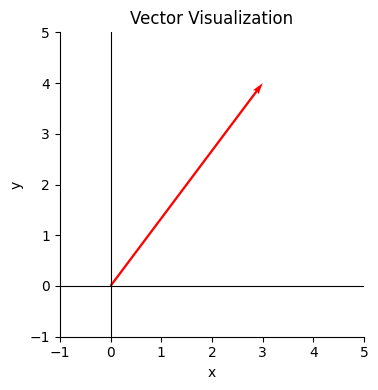

4.1 passed ✓  |v| = 5.0


In [14]:
v = np.array([3, 4])
norm_v = np.linalg.norm(v)

M = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

fig, ax = plt.subplots()
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red')
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8)
ax.axvline(0, color='k', lw=0.8)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

In [15]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ = P + Q
scalar3P = 3 * P
PQ = P @ Q
QP = Q @ P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]
Eigenpair 0: Av = [3.53553391 3.53553391], λv = [3.53553391 3.53553391] ✓
Eigenpair 1: Av = [-0.89442719  1.78885438], λv = [-0.89442719  1.78885438] ✓


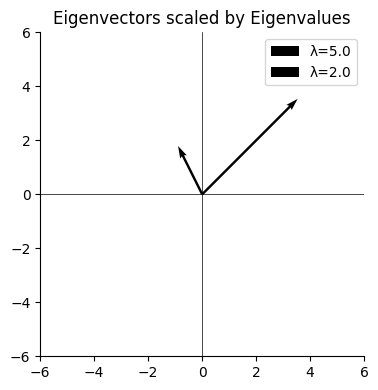

4.3 passed ✓


In [16]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

for i in range(len(eigenvalues)):
    lhs = A @ eigenvectors[:, i]
    rhs = eigenvalues[i] * eigenvectors[:, i]
    assert np.allclose(lhs, rhs)
    print(f"Eigenpair {i}: Av = {lhs}, λv = {rhs} ✓")

fig, ax = plt.subplots()
origin = [0, 0]
for i in range(len(eigenvalues)):
    scaled = eigenvalues[i] * eigenvectors[:, i]
    ax.quiver(*origin, scaled[0], scaled[1], angles='xy', scale_units='xy', scale=1, label=f'λ={eigenvalues[i]:.1f}')
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.legend()
ax.set_title('Eigenvectors scaled by Eigenvalues')
plt.tight_layout()
plt.show()

print("4.3 passed ✓")

**Your Geometric Explanation (4.3):**

> Eigenvalues and eigenvectors reveal the directions along which a linear transformation acts by pure scaling. An eigenvector is a direction that does not rotate when the matrix is applied — it only gets stretched or compressed. The eigenvalue tells you the scaling factor: values greater than 1 stretch the vector, values between 0 and 1 shrink it, and negative values flip its direction. Geometrically, a matrix transforms all of space, but along its eigenvector directions, the transformation simplifies to just multiplication by a scalar.

### 4.4 SVD & Dimensionality Reduction

In [17]:
np.random.seed(42)
X = np.random.randn(4, 3)

U, S, Vt = np.linalg.svd(X, full_matrices=False)

X_reconstructed = U @ np.diag(S) @ Vt
X_approx = S[0] * np.outer(U[:, 0], Vt[0, :])

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 8.01e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

> In SVD, the matrix X is decomposed as X = U·S·Vᵀ. U contains the left singular vectors (how data points relate to components), S is a diagonal matrix of singular values (capturing the magnitude/importance of each component), and Vᵀ contains the right singular vectors (the principal directions in feature space). When the data is centered, the right singular vectors Vᵀ are exactly the principal components from PCA, and the singular values are related to the eigenvalues of the covariance matrix. Vᵀ contains the directions of maximum variance.

## Part 5 — Statistics
### 5.1 Descriptive vs Inferential Statistics

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


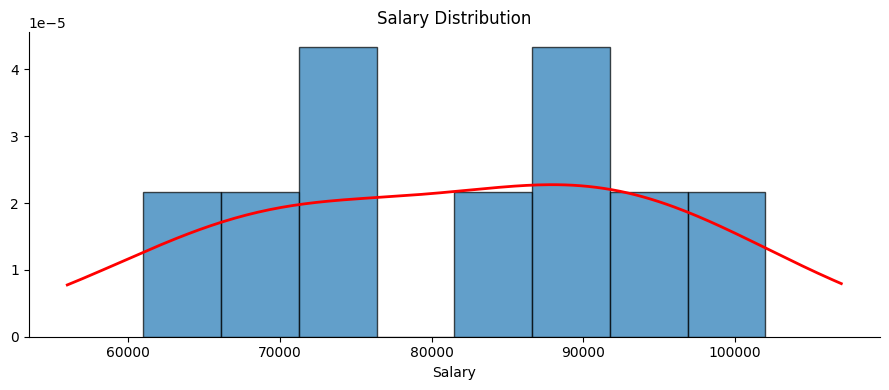

In [18]:
salary = df_filled['salary']

mean_s = salary.mean()
median_s = salary.median()
std_s = salary.std()
min_s = salary.min()
max_s = salary.max()
iqr_s = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

fig, ax = plt.subplots()
ax.hist(salary, bins=8, density=True, alpha=0.7, edgecolor='black')
xmin, xmax = salary.min() - 5000, salary.max() + 5000
x_kde = np.linspace(xmin, xmax, 200)
kde = stats.gaussian_kde(salary)
ax.plot(x_kde, kde(x_kde), 'r-', lw=2)
ax.set_xlabel('Salary')
ax.set_title('Salary Distribution')
plt.tight_layout()
plt.show()

**Definitions (5.1):**

- **Population:** The entire group of individuals or observations that we want to study and draw conclusions about.
- **Sample:** A subset of the population selected for measurement and analysis.
- **Descriptive statistic:** A numerical summary (like mean, median, std) that describes the characteristics of an observed dataset.
- **Inferential statistic:** A method that uses sample data to make generalizations, predictions, or decisions about a larger population.

### 5.2 Hypothesis Testing

In [19]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

t_stat, p_value = stats.ttest_1samp(eng_salaries, overall_mean)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

r, r_pval = stats.pearsonr(df_filled['salary'], df_filled['years_exp'])
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- **H₀:** The mean salary of Engineering employees is equal to the overall company mean salary (μ_eng = μ_overall).
- **H₁:** The mean salary of Engineering employees is significantly different from (greater than) the overall company mean salary (μ_eng > μ_overall).
- **Conclusion:** Based on the p-value, if p < 0.05 we reject H₀ and conclude that Engineering salaries are significantly higher than the company average. The Pearson correlation coefficient r indicates the strength and direction of the linear relationship between salary and years of experience.

### 5.3 Error Metrics

In [20]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

mae = np.mean(np.abs(y_true - y_pred))
mse = np.mean((y_true - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - ss_res / ss_tot
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

In [21]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

ts_diff = np.diff(ts)
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

PSI: 1.9099
Shift severity: Major


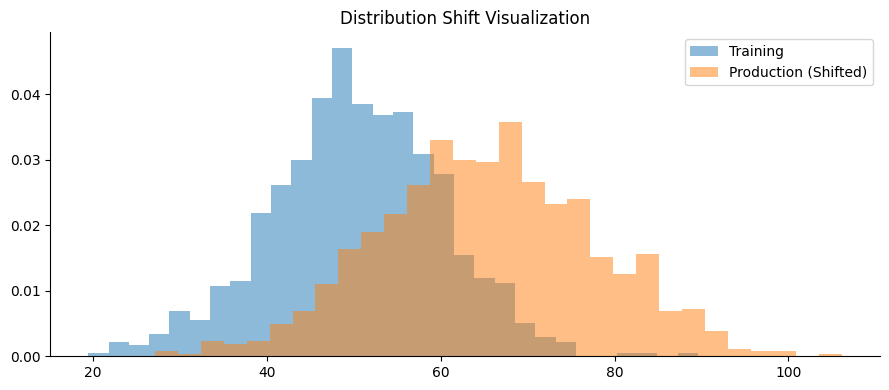

In [22]:
def compute_psi(expected, actual, bins=10):
    breakpoints = np.linspace(
        min(expected.min(), actual.min()),
        max(expected.max(), actual.max()),
        bins + 1
    )
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]
    expected_pct = expected_counts / len(expected) + 1e-10
    actual_pct = actual_counts / len(actual) + 1e-10
    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)
drift_dist = np.random.normal(65, 12, 1000)

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, alpha=0.5, label='Training', density=True)
ax.hist(drift_dist, bins=30, alpha=0.5, label='Production (Shifted)', density=True)
ax.legend()
ax.set_title('Distribution Shift Visualization')
plt.tight_layout()
plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** The relationship between input features and the target variable changes over time (P(Y|X) changes).
- **Covariate drift:** The distribution of input features changes over time (P(X) changes), while the relationship P(Y|X) remains the same.
- **PSI < 0.1:** No significant shift — model is stable.
- **PSI 0.1–0.2:** Minor shift detected — monitor closely.
- **PSI > 0.2:** Major shift — model retraining is recommended.
- **Retraining trigger example:** When PSI exceeds 0.2 on key input features for two consecutive monitoring windows, trigger an automated retraining pipeline.

## Part 6 — Probability Theory
### 6.1 Core Concepts

In [23]:
total = 10
red, blue, green = 4, 3, 3

p_red = red / total
p_blue = blue / total
p_green = green / total

p_red_then_blue = (red / total) * (blue / (total - 1))

p_blue_given_red = blue / (total - 1)

independent = (p_blue_given_red == p_blue)

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

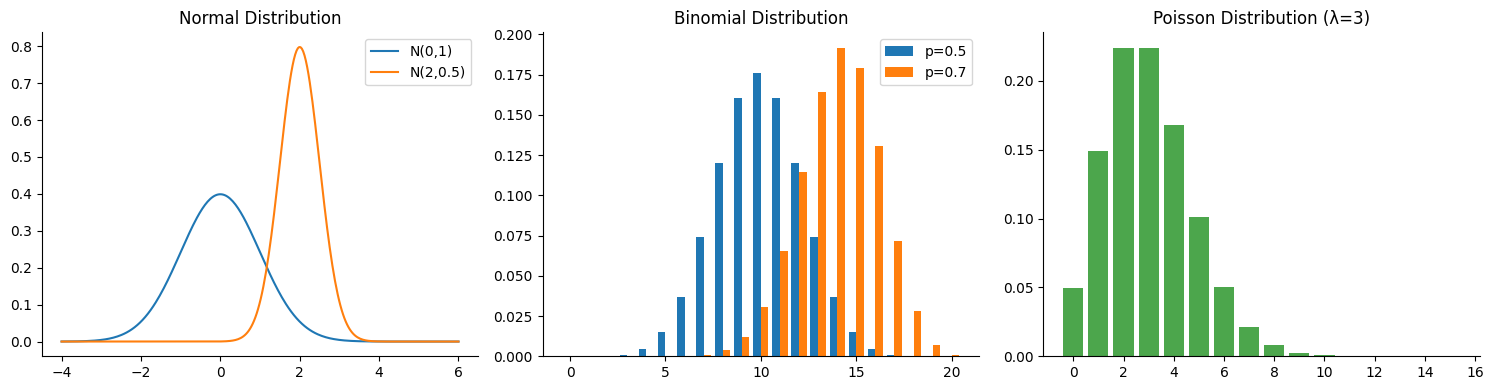

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-4, 6, 300)
axes[0].plot(x, stats.norm.pdf(x, 0, 1), label='N(0,1)')
axes[0].plot(x, stats.norm.pdf(x, 2, 0.5), label='N(2,0.5)')
axes[0].legend()
axes[0].set_title('Normal Distribution')

k = np.arange(0, 21)
axes[1].bar(k - 0.2, stats.binom.pmf(k, 20, 0.5), width=0.4, label='p=0.5')
axes[1].bar(k + 0.2, stats.binom.pmf(k, 20, 0.7), width=0.4, label='p=0.7')
axes[1].legend()
axes[1].set_title('Binomial Distribution')

k2 = np.arange(0, 16)
axes[2].bar(k2, stats.poisson.pmf(k2, 3), color='green', alpha=0.7)
axes[2].set_title('Poisson Distribution (λ=3)')

plt.tight_layout()
plt.show()

### 6.3 Bayes' Theorem

In [25]:
p_spam = 0.30
p_free_given_spam = 0.80
p_free_given_ham = 0.05
p_ham = 1 - p_spam

p_free = p_free_given_spam * p_spam + p_free_given_ham * p_ham

p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    prior_ham = 1 - prior_spam
    evidence = p_word_given_spam * prior_spam + p_word_given_ham * prior_ham
    return (p_word_given_spam * prior_spam) / evidence

pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|----------------|
| Prior | P(Spam) | 0.30 — our initial belief that any email is spam |
| Likelihood | P("free" \| Spam) | 0.80 — probability of seeing "free" in a spam email |
| Evidence | P("free") | 0.275 — total probability of seeing "free" in any email |
| Posterior | P(Spam \| "free") | 0.8727 — updated probability of spam after observing "free" |

### 6.4 Central Limit Theorem

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 0.9971, std: 0.1828
CLT predicted std: 0.1827


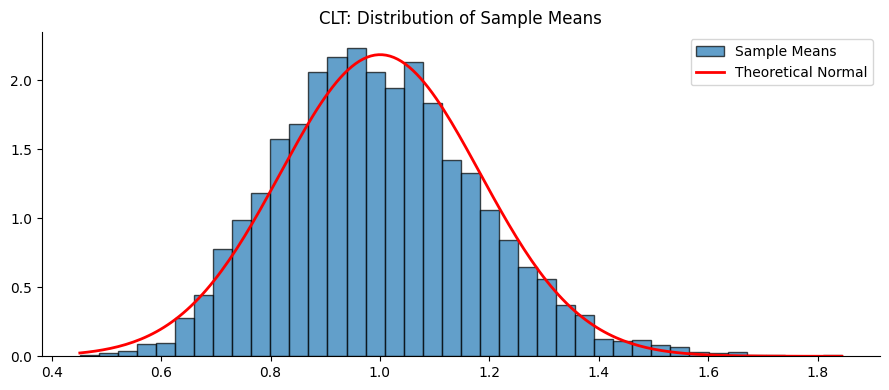

KS test p-value: 0.0000 → Approximately normal? False


In [26]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30
sample_means = np.array([np.random.choice(population, sample_size).mean() for _ in range(n_samples)])

pop_mean = population.mean()
pop_std = population.std()
clt_std = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

fig, ax = plt.subplots()
ax.hist(sample_means, bins=40, density=True, alpha=0.7, edgecolor='black', label='Sample Means')
x_range = np.linspace(sample_means.min(), sample_means.max(), 200)
ax.plot(x_range, stats.norm.pdf(x_range, pop_mean, clt_std), 'r-', lw=2, label='Theoretical Normal')
ax.legend()
ax.set_title('CLT: Distribution of Sample Means')
plt.tight_layout()
plt.show()

ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

> The Central Limit Theorem is foundational because it guarantees that the distribution of sample means approaches a normal distribution regardless of the population's original shape, as long as the sample size is sufficiently large. This matters enormously for ML and statistics because it justifies the use of normal-distribution-based methods (confidence intervals, t-tests, z-tests) even when the underlying data is not normally distributed. The CLT underpins the assumption in many classical statistical tests that test statistics follow a normal distribution under the null hypothesis.

## 🏁 Submission Checklist

- [x] All `assert` blocks pass without errors
- [x] All `# YOUR CODE HERE` cells are filled
- [x] All markdown reflection cells are filled in your own words
- [x] All plots render with labels and titles
- [x] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`